In [2]:
import pandas as pd

In [3]:
animal_path="/content/drive/MyDrive/animals_dataset"

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [5]:
train_data = tf.keras.utils.image_dataset_from_directory(
   "/content/drive/MyDrive/animals_dataset/train",
    image_size = (128, 128),
    batch_size=32,
    subset = "training",
    validation_split = 0.2,
    seed = 42

)

Found 464 files belonging to 5 classes.
Using 372 files for training.


In [8]:
test_data = tf.keras.utils.image_dataset_from_directory(
   "/content/drive/MyDrive/animals_dataset/test",
    image_size = (128, 128),
    batch_size=32,
    subset = "validation",
    validation_split = 0.2,
    seed = 42

)

Found 82 files belonging to 5 classes.
Using 16 files for validation.


In [11]:
val_data=tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/animals_dataset/validation",
    image_size = (128, 128),
    batch_size=32,
    subset = "validation",
    validation_split = 0.2,
    seed = 42
)

Found 83 files belonging to 5 classes.
Using 16 files for validation.


In [12]:
import cv2
from PIL import Image
from IPython.display import display

In [13]:
display(Image.open("/content/drive/MyDrive/animals_dataset/train/cat/Grumpy cat 2.jpeg"))

Output hidden; open in https://colab.research.google.com to view.

array([[[ 42,  72,  59],
        [ 61,  91,  78],
        [ 61,  88,  78],
        ...,
        [ 31,  57,  43],
        [ 33,  59,  43],
        [ 35,  61,  45]],

       [[ 57,  87,  74],
        [ 63,  93,  80],
        [ 64,  94,  83],
        ...,
        [ 28,  56,  43],
        [ 30,  57,  41],
        [ 32,  58,  44]],

       [[ 62,  95,  81],
        [ 55,  88,  74],
        [ 62,  94,  83],
        ...,
        [ 25,  55,  44],
        [ 27,  56,  41],
        [ 28,  56,  43]],

       ...,

       [[ 43,  90, 128],
        [ 23,  69, 116],
        [ 62, 107, 168],
        ...,
        [ 69,  88, 121],
        [ 77,  96, 129],
        [126, 145, 178]],

       [[ 84, 131, 169],
        [ 44,  91, 135],
        [ 18,  64, 122],
        ...,
        [ 71,  90, 123],
        [ 83, 102, 135],
        [136, 155, 188]],

       [[ 21,  69, 105],
        [ 41,  89, 131],
        [ 49,  95, 153],
        ...,
        [ 56,  75, 108],
        [ 73,  92, 125],
        [133, 152, 185]]], dtype=uint8)
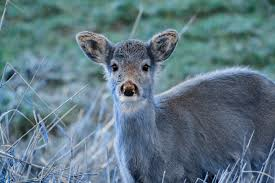

In [14]:
cv2.imread("/content/drive/MyDrive/animals_dataset/train/deep/download (6).jpeg")

In [15]:
model=keras.Sequential([
    layers.Conv2D(64,(3,3),padding="same"),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128,(3,3),padding="same"),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(256,(3,3),padding="same"),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dense(5,activation="softmax")
])

In [18]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [21]:
model.fit(train_data,epochs=10,validation_data=val_data)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9812 - loss: 0.0487 - val_accuracy: 0.5625 - val_loss: 4.7122
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9946 - loss: 0.0348 - val_accuracy: 0.5625 - val_loss: 4.0577
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9973 - loss: 0.0113 - val_accuracy: 0.5625 - val_loss: 4.7963
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 1.0000 - loss: 0.0074 - val_accuracy: 0.5625 - val_loss: 4.8286
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 1.0000 - loss: 0.0050 - val_accuracy: 0.5625 - val_loss: 4.8572
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.5625 - val_loss: 4.7584
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 0.5625 - val_loss: 4.7452
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.5625 - v

In [33]:
import numpy as np
import tensorflow as tf
import gradio as gr

def pred_image(img):
    img = img.resize((128, 128))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_array)
    score = pred
    prediction = train_data.class_names[np.argmax(score)]
    confidence = float(np.max(score))
    return prediction, confidence

demo = gr.Interface(
    fn=pred_image,
    inputs=gr.Image(type="pil"),
    outputs=[
        gr.Textbox(label="Predicted Species"),
        gr.Label(label="Confidence Score")
    ]
)

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e885dcb07660527c87.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
